In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def generate_research_signal(L=500, L_sw=64, N_f=100, snr_db=0, offset=None):
    """
    L: Total Frame Length
    L_sw: Sync Word Length
    N_f: Number of Frames
    snr_db: Signal-to-Noise Ratio
    offset: Random starting delay (if None, it picks a random value)
    """
    # 1. Create a fixed Sync Word (The 'Signature')
    sw = np.random.choice([-1, 1], size=L_sw)
    
    # 2. Build the full stream [SW + Data] * N_f
    full_stream = []
    for _ in range(N_f):
        payload = np.random.choice([-1, 1], size=L - L_sw)
        frame = np.concatenate([sw, payload])
        full_stream.extend(frame)
    
    # 3. Apply the 'Blind' Offset (Shift the whole signal)
    if offset is None:
        offset = np.random.randint(0, L)
    signal = np.roll(np.array(full_stream), offset)
    
    # 4. Add AWGN Noise
    snr_linear = 10**(snr_db / 10.0)
    noise_std = np.sqrt(1 / (2 * snr_linear))
    r = signal + np.random.normal(0, noise_std, len(signal))
    
    return r, L, offset, sw

In [12]:
def estimate_blind_params(r, L_guess_max=1000, W=2000):
    # Sliding Correlation
    C = []
    ref_window = r[:W]
    for tau in range(1, L_guess_max):
        test_window = r[tau : tau + W]
        C.append(np.mean(ref_window * test_window))
    
    C = np.array(C)
    
    # Find Peaks (Threshold at 40% of maximum)
    peaks = np.where(C > np.max(C) * 0.4)[0]
    
    if len(peaks) < 2:
        return None, C
    
    # Calculate most frequent distance between peaks
    diffs = np.diff(peaks)
    L_est = int(stats.mode(diffs, keepdims=True)[0][0])
    
    return L_est, C

In [13]:
# Configuration
true_L = 500
snr_range = np.arange(-10, 11, 2)
window_sizes = [500, 1000, 2000, 4000]
trials = 20

results_matrix = np.zeros((len(window_sizes), len(snr_range)))

print("Starting Parameter Sweep...")
for i, W in enumerate(window_sizes):
    for j, snr in enumerate(snr_range):
        success = 0
        for _ in range(trials):
            r, _, _, _ = generate_research_signal(L=true_L, snr_db=snr)
            L_est, _ = estimate_blind_params(r, L_guess_max=true_L*2, W=W)
            
            if L_est == true_L:
                success += 1
        results_matrix[i, j] = (success / trials) * 100
    print(f"Finished Window Size W={W}")

Starting Parameter Sweep...
Finished Window Size W=500
Finished Window Size W=1000
Finished Window Size W=2000
Finished Window Size W=4000


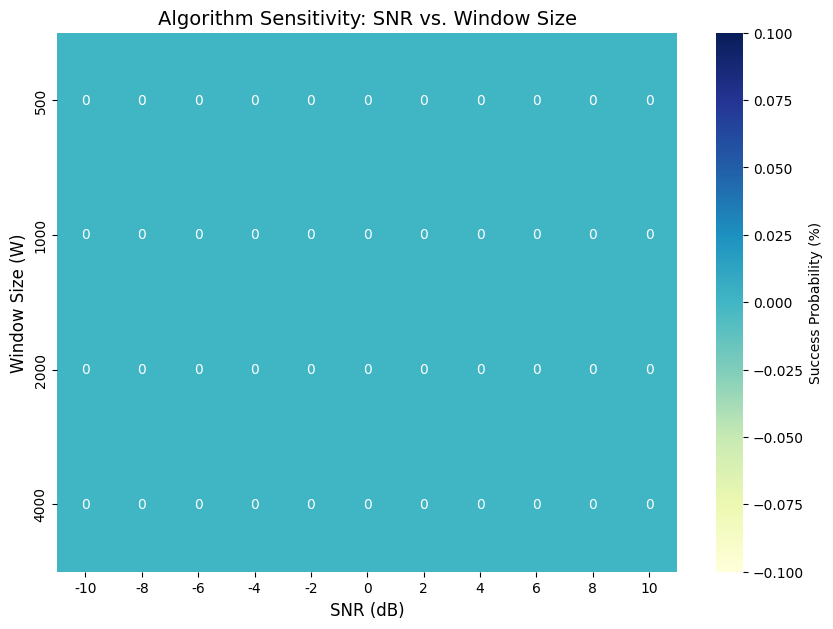

In [14]:
plt.figure(figsize=(10, 7))
# Fixed 'cbar_kws' to avoid the AttributeError from before
sns.heatmap(results_matrix, annot=True, fmt=".0f", cmap="YlGnBu",
            xticklabels=snr_range, yticklabels=window_sizes,
            cbar_kws={'label': 'Success Probability (%)'})

plt.title("Algorithm Sensitivity: SNR vs. Window Size", fontsize=14)
plt.xlabel("SNR (dB)", fontsize=12)
plt.ylabel("Window Size (W)", fontsize=12)
plt.show()

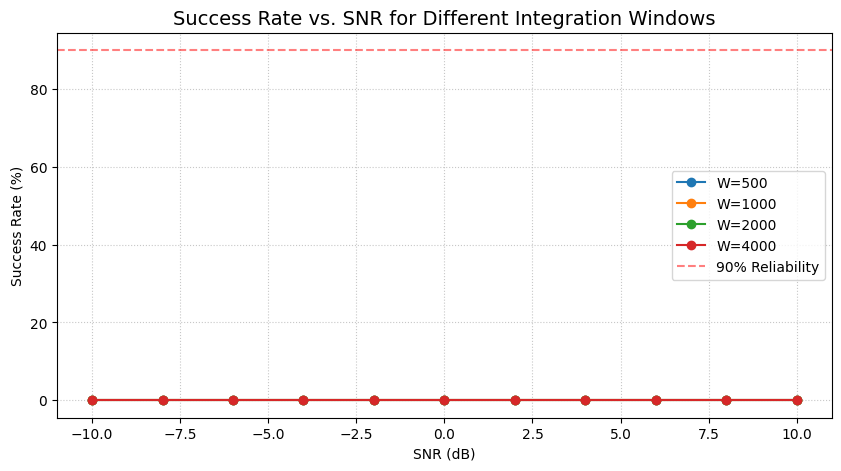

In [15]:
plt.figure(figsize=(10, 5))
for i, W in enumerate(window_sizes):
    plt.plot(snr_range, results_matrix[i, :], marker='o', label=f'W={W}')

plt.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='90% Reliability')
plt.title("Success Rate vs. SNR for Different Integration Windows", fontsize=14)
plt.xlabel("SNR (dB)")
plt.ylabel("Success Rate (%)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [16]:
import numpy as np

def generate_signal(L=500, L_sw=64, N_f=100, snr_db=0, offset=None):
    
    sw = np.random.choice([-1, 1], size=L_sw)

    frames = []
    for _ in range(N_f):
        payload = np.random.choice([-1, 1], size=L - L_sw)
        frame = np.concatenate([sw, payload])
        frames.append(frame)

    signal = np.concatenate(frames)

    if offset is None:
        offset = np.random.randint(0, L)
    signal = np.roll(signal, offset)

    # --- Correct SNR ---
    snr_linear = 10**(snr_db/10)
    signal_power = np.mean(signal**2)
    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)

    noise = np.random.normal(0, noise_std, len(signal))
    r = signal + noise

    return r, L

In [17]:
def compute_correlation(r, tau_max=1000, W=2000):

    C = []
    ref = r[:W]

    for tau in range(1, tau_max):
        test = r[tau:tau+W]

        if len(test) < W:
            break

        numerator = np.sum(ref * test)
        denom = np.sqrt(np.sum(ref**2) * np.sum(test**2))
        C.append(numerator / denom)

    return np.array(C)

In [18]:
from scipy.signal import find_peaks
from scipy.stats import mode

def estimate_frame_length(C, height=0.3):

    peaks, _ = find_peaks(C, height=height)

    if len(peaks) < 2:
        return None

    diffs = np.diff(peaks)

    return int(mode(diffs, keepdims=True)[0][0])

In [19]:
def run_experiment(true_L, snr_db, W, trials=20):

    success = 0

    for _ in range(trials):
        r, _ = generate_signal(L=true_L, snr_db=snr_db)
        C = compute_correlation(r, tau_max=true_L*2, W=W)
        L_est = estimate_frame_length(C)

        if L_est == true_L:
            success += 1

    return (success / trials) * 100

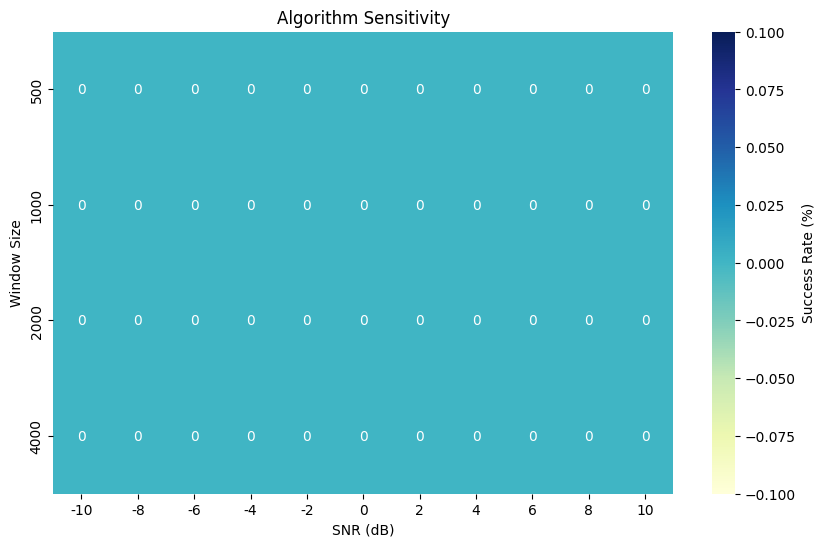

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

true_L = 500
snr_range = np.arange(-10, 11, 2)
window_sizes = [500, 1000, 2000, 4000]

results = np.zeros((len(window_sizes), len(snr_range)))

for i, W in enumerate(window_sizes):
    for j, snr in enumerate(snr_range):
        results[i, j] = run_experiment(true_L, snr, W)

plt.figure(figsize=(10,6))
sns.heatmap(results,
            annot=True,
            fmt=".0f",
            xticklabels=snr_range,
            yticklabels=window_sizes,
            cmap="YlGnBu",
            cbar_kws={'label': 'Success Rate (%)'})

plt.xlabel("SNR (dB)")
plt.ylabel("Window Size")
plt.title("Algorithm Sensitivity")
plt.show()